<center><img src="images/clothing.jpg"></center>

Welcome to the world of e-commerce, where customer feedback is a goldmine of insights! In this project, you'll dive into the Women's Clothing E-Commerce Reviews dataset, focusing on the 'Review Text' column filled with direct customer opinions.

Your mission is to use text embeddings and Python to analyze these reviews, uncover underlying themes, and understand customer sentiments. This analysis will help improve customer service and product offerings.

## The Data

You will be working with a dataset specifically focusing on customer reviews. Below is the data dictionary for the relevant field:

## womens_clothing_e-commerce_reviews.csv

| Column        | Description                           |
|---------------|---------------------------------------|
| `'Review Text'` | Textual feedback provided by customers about their shopping experience and product quality. |

Armed with access to powerful embedding API services, you will process the reviews, extract meaningful insights, and present your findings.

Let's get started!

## Install useful libraries

In [27]:
# Run this cell to install ChromaDB if desired
try:
    assert version('chromadb') == '0.4.17'
except:
    !pip install chromadb==0.4.17
try:
    assert version('pysqlite3') == '0.5.2'
except:
    !pip install pysqlite3-binary==0.5.2
__import__('pysqlite3')
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')
import chromadb

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Load the dataset
Load data and perform basic data checks to ensure you are using relevant data for the analysis

In [28]:
# Load the dataset
import pandas as pd
reviews = pd.read_csv("womens_clothing_e-commerce_reviews.csv")

# Display the first few entries
reviews.head()

,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [29]:
# Start coding here
# Use as many cells as you need.
from chromadb.utils import embedding_functions

# Clean missing values and get a list of reviews
reviews_clean = reviews.dropna(subset=['Review Text'])
reviews_list = reviews_clean['Review Text'].tolist()

# Initialize the embedding function
embed_fn = embedding_functions.DefaultEmbeddingFunction()

# Generate and store the embeddings as a list
embeddings = embed_fn(reviews_list)

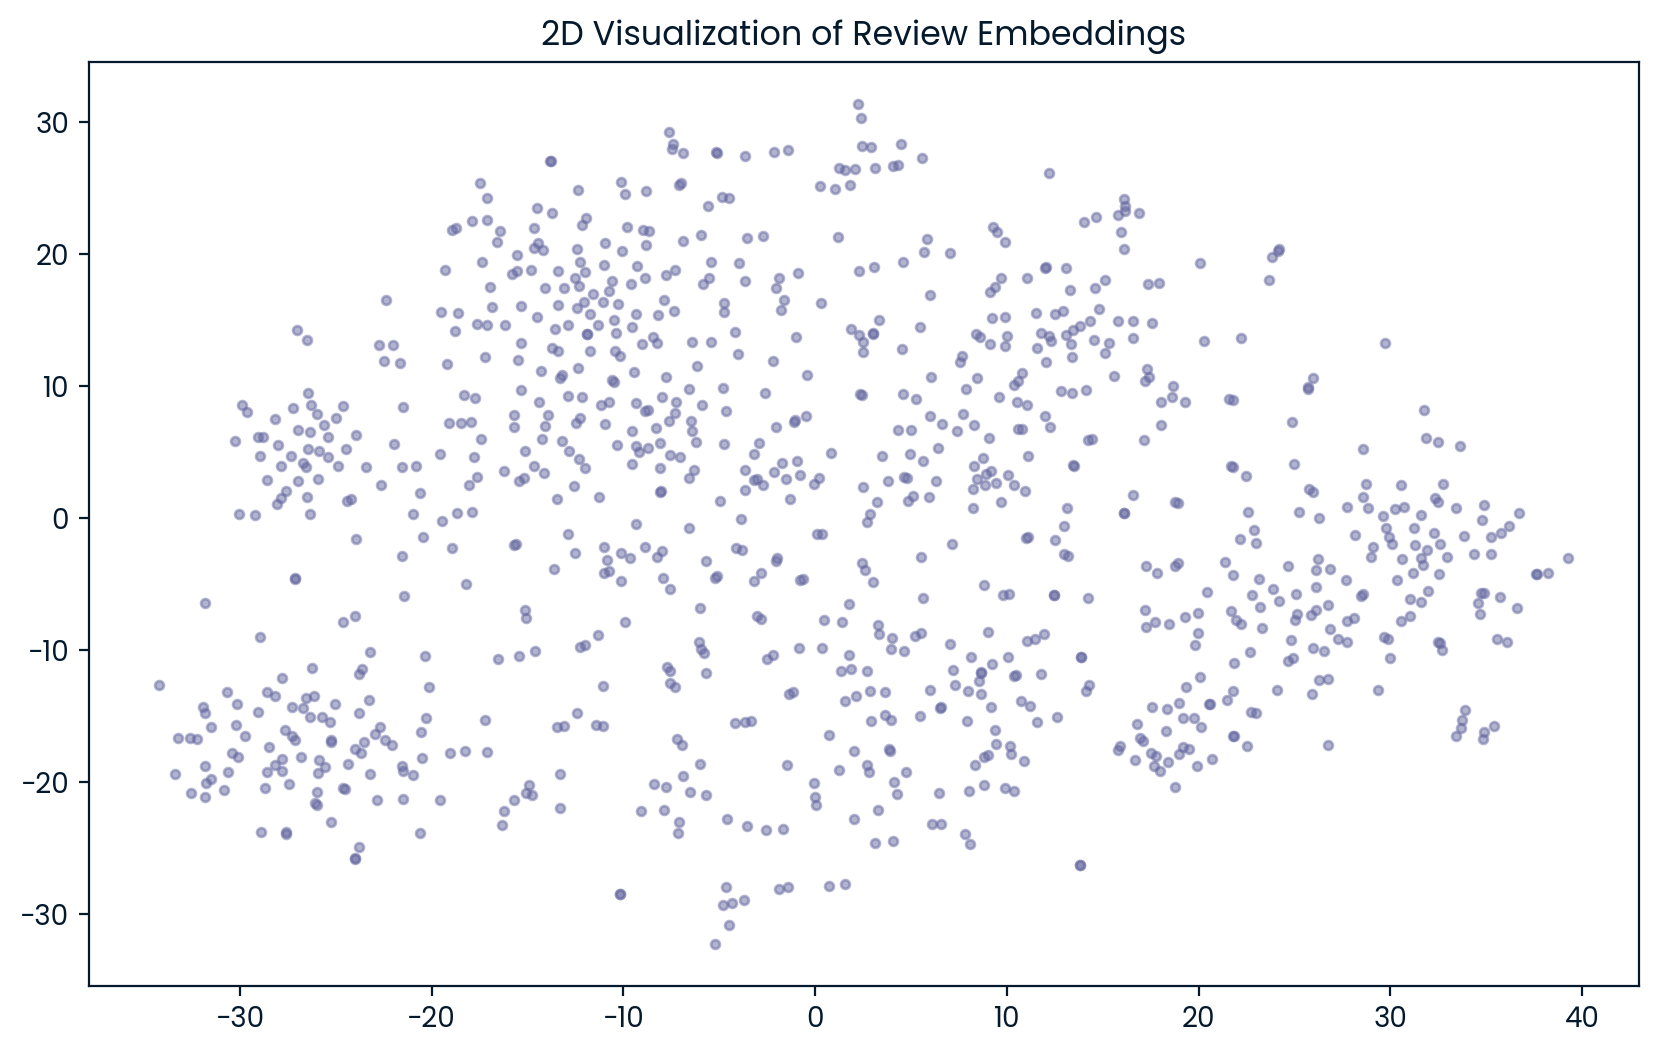

In [30]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Apply t-SNE to reduce to 2 dimensions
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

# Plot the 2D visual representation
plt.figure(figsize=(10, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, s=10)
plt.title('2D Visualization of Review Embeddings')
plt.show()

In [31]:
from scipy.spatial.distance import cdist

# Define topics and embed them
categories = ['quality', 'fit', 'style', 'comfort']
category_embeddings = embed_fn(categories)

# Calculate the distances between the topics and all review embeddings
distances = cdist(category_embeddings, embeddings, metric='cosine')

# Print an example of a review that closely matches each category
for i, category in enumerate(categories):
    closest_idx = np.argmin(distances[i])
    print(f"Closest review to '{category}': {reviews_list[closest_idx]}\n")

Closest review to 'quality': I bought this and like other reviews, agree that the quality probably could be better, but i still love it enough to keep. the buckle fell apart, but i was able to fix it and the zipper seems a little weak. it has pilled, but the fabric is textured, so i didn't even notice until i read the other reviews and then looked back at my jacket.  it is a perfect medium coat for 40's & 50's before i am ready to bust out my ugly down north face for winter.  i get compliments every time i wear it!  love!!

Closest review to 'fit': Perfect fit. did not lose its shape. thicker material. great quality for a great price. definitely  a wardrobe  staple. can be dressed up or down. work (business) appropriate. fits tts. for reference,  i am 5'0", 109lbs, and the 00 petite fits perfect. falls right above ankle like pictured. if they had more colours, i would get them too :)

Closest review to 'style': Great style!

Closest review to 'comfort': Super soft and comfortable. runs

In [32]:
import chromadb

# 1. Initialize the ChromaDB client
client = chromadb.Client()

# (Optional) Delete the collection if it already exists from a previous run to avoid errors
try:
    client.delete_collection(name="clothing_reviews")
except ValueError:
    pass

# 2. Create a new collection using our default embedding function
collection = client.create_collection(
    name="clothing_reviews",
    embedding_function=embed_fn
)

# 3. Add our reviews to the collection
# ChromaDB requires unique string IDs for each document
review_ids = [str(i) for i in range(len(reviews_list))]

print("Adding documents to ChromaDB... (this might take a moment)")
collection.add(
    documents=reviews_list,
    ids=review_ids
)
print("Done!")

# 4. Define the updated similarity search function
def find_closest_reviews(input_review, n=3):
    # Query the ChromaDB collection
    results = collection.query(
        query_texts=[input_review],
        n_results=n
    )
    
    # Extract and return the list of matching documents
    # results['documents'] is a list of lists, so we grab the first one [0]
    return results['documents'][0]

# 5. Apply the function to the target review
target_review = "Absolutely wonderful - silky and sexy and comfortable"
most_similar_reviews = find_closest_reviews(target_review, n=3)

print("\n--- Similarity Search Results ---")
print(f"Target: '{target_review}'\n")

for i, review in enumerate(most_similar_reviews, 1):
    print(f"{i}. {review}")

Adding documents to ChromaDB... (this might take a moment)
Done!

--- Similarity Search Results ---
Target: 'Absolutely wonderful - silky and sexy and comfortable'

1. Absolutely wonderful - silky and sexy and comfortable
2. Very comfortable and versatile. got lots of compliments.
3. Very cute, very comfortable. for me aesthetics and comfort must go hand in hand. this dress fits the bill.
